# Fine-tuning ResNet-18 on CIFAR-100 with MindCV and MindSpore

[Transfer learning](https://en.wikipedia.org/wiki/Transfer_learning) is the practice of adapting a pre-trained model for a new but related task. An example of transfer learning is [low-rank adaptation \(LoRA\)](https://arxiv.org/abs/2106.09685), a common technique in LLM fine-tuning.

In this notebook experiment, let's load [ResNet-18](https://en.wikipedia.org/wiki/Residual_neural_network) with [MindCV](https://mindspore-lab.github.io/mindcv/) for fine-tuning on the [CIFAR-100](https://www.cs.toronto.edu/~kriz/cifar.html) dataset. ResNet-18 is a modern CNN pre-trained on [ImageNet](https://www.image-net.org/) which makes it suitable for our task as both datasets represent image classification tasks. Furthermore, ImageNet contains far more samples and categories than CIFAR-100, meaning the pre-trained filters from ImageNet should translate well to CIFAR-100 with minor adjustments.

## Prerequisites

For the best experience following this notebook experiment, it's recommended to go through the first 8 chapters of the [D2L](https://d2l.ai/chapter_convolutional-modern/index.html) textbook or have equivalent experience with machine learning.

## Installing software packages and dependencies

This notebook experiment was performed on the [OrangePi AIpro \(20T\)](http://www.orangepi.org/html/hardWare/computerAndMicrocontrollers/details/Orange-Pi-AIpro%2820t%29.html) development board. The software used in this notebook are listed below.

1. Ubuntu 22.04 LTS
1. Python 3.12
1. MindSpore 2.9.0
1. CANN 9.0.0
1. [MindCV](https://mindspore-lab.github.io/mindcv/) commit `51b0636da1e38a44a52edf76cf314d1c7c18883a` \(2025-07-24\)

In [1]:
!cat requirements.txt

absl-py==2.4.0
attrs==26.1.0
cloudpickle==3.1.2
decorator==5.2.1
git+https://github.com/mindspore-lab/mindcv.git@51b0636da1e38a44a52edf76cf314d1c7c18883a
jupyterlab==4.5.7
jupyterlab-git==0.53.0
jupyter-resource-usage==1.2.1
loguru==0.7.3
matplotlib==3.10.9
mindspore==2.9.0
ml-dtypes==0.5.4
msguard==0.0.8
openpyxl==3.1.5
opentelemetry-exporter-otlp-proto-grpc==1.33.1
opentelemetry-exporter-otlp-proto-http==1.33.1
pandas~=2.2
plotly>=5.11.0
pydantic==2.13.4
sympy==1.14.0
tornado==6.5.5


In [2]:
%pip install -r requirements.txt

  Cloning https://github.com/mindspore-lab/mindcv.git (to revision 51b0636da1e38a44a52edf76cf314d1c7c18883a) to /tmp/pip-req-build-athjd9sc
  Running command git clone --filter=blob:none --quiet https://github.com/mindspore-lab/mindcv.git /tmp/pip-req-build-athjd9sc
  Running command git rev-parse -q --verify 'sha^51b0636da1e38a44a52edf76cf314d1c7c18883a'
  Running command git fetch -q https://github.com/mindspore-lab/mindcv.git 51b0636da1e38a44a52edf76cf314d1c7c18883a
  Resolved https://github.com/mindspore-lab/mindcv.git to commit 51b0636da1e38a44a52edf76cf314d1c7c18883a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## Loading and visualizing the CIFAR-100 dataset

The [`mindcv.create_dataset`](https://mindspore-lab.github.io/mindcv/reference/data/#mindcv.data.dataset_factory.create_dataset) allows us to load the CIFAR-100 dataset with a single line of code. Let's take just the first 4 samples and visualize them with Matplotlib.

In [4]:
import mindcv

visual_ds = mindcv.create_dataset('cifar100', split='train', download=True)
visual_ds = visual_ds.batch(batch_size=4)
visual_ds

Our dataset contains 3 columns.

1. `image`: the image containing the object we wish to classify
1. `coarse_label`: a coarse label indicating the broad category that our object belongs to, e.g. insects, flowers, or people. There are 20 coarse labels in CIFAR-100
1. `fine_label`: a fine label indicating the precise category that our objects belongs to, e.g. bee, orchid or girl. There are 100 fine labels in CIFAR-100

Since CIFAR-100 includes both coarse and fine labels with a hierarchical relationship between the two, i.e. we can't have a flower which is a girl, it's a canonical example of [hierarchical classification](https://en.wikipedia.org/wiki/Hierarchical_classification).

In [5]:
visual_ds.get_col_names()

['image', 'coarse_label', 'fine_label']

Let's inspect the shapes of our sample features and labels.

In [6]:
X_samples, y0_samples, y1_samples = next(visual_ds.create_tuple_iterator())
X_samples.shape, y0_samples.shape, y1_samples.shape

((4, 32, 32, 3), (4,), (4,))

Below, we define mappings from the raw integer labels to their human-readable equivalents. This mapping is taken from the CIFAR-100 dataset on [Hugging Face](https://huggingface.co/datasets/uoft-cs/cifar100).

In [7]:
y0_labels = [
    'aquatic_mammals',
    'fish',
    'flowers',
    'food_containers',
    'fruit_and_vegetables',
    'household_electrical_devices',
    'household_furniture',
    'insects',
    'large_carnivores',
    'large_man-made_outdoor_things',
    'large_natural_outdoor_scenes',
    'large_omnivores_and_herbivores',
    'medium_mammals',
    'non-insect_invertebrates',
    'people',
    'reptiles',
    'small_mammals',
    'trees',
    'vehicles_1',
    'vehicles_2'
]
len(y0_labels)

20

In [8]:
y1_labels = [
    'apple',
    'aquarium_fish',
    'baby',
    'bear',
    'beaver',
    'bed',
    'bee',
    'beetle',
    'bicycle',
    'bottle',
    'bowl',
    'boy',
    'bridge',
    'bus',
    'butterfly',
    'camel',
    'can',
    'castle',
    'caterpillar',
    'cattle',
    'chair',
    'chimpanzee',
    'clock',
    'cloud',
    'cockroach',
    'couch',
    'cra',
    'crocodile',
    'cup',
    'dinosaur',
    'dolphin',
    'elephant',
    'flatfish',
    'forest',
    'fox',
    'girl',
    'hamster',
    'house',
    'kangaroo',
    'keyboard',
    'lamp',
    'lawn_mower',
    'leopard',
    'lion',
    'lizard',
    'lobster',
    'man',
    'maple_tree',
    'motorcycle',
    'mountain',
    'mouse',
    'mushroom',
    'oak_tree',
    'orange',
    'orchid',
    'otter',
    'palm_tree',
    'pear',
    'pickup_truck',
    'pine_tree',
    'plain',
    'plate',
    'poppy',
    'porcupine',
    'possum',
    'rabbit',
    'raccoon',
    'ray',
    'road',
    'rocket',
    'rose',
    'sea',
    'seal',
    'shark',
    'shrew',
    'skunk',
    'skyscraper',
    'snail',
    'snake',
    'spider',
    'squirrel',
    'streetcar',
    'sunflower',
    'sweet_pepper',
    'table',
    'tank',
    'telephone',
    'television',
    'tiger',
    'tractor',
    'train',
    'trout',
    'tulip',
    'turtle',
    'wardrobe',
    'whale',
    'willow_tree',
    'wolf',
    'woman',
    'worm'
]
len(y1_labels)

100

Now we visualize our 4 samples with Matplotlib. The main reason we chose 4 samples instead of 10 as we have done before is because the names for some of these categories are rather long and it's difficult to get Matplotlib to get them to display properly without overlapping text and images.

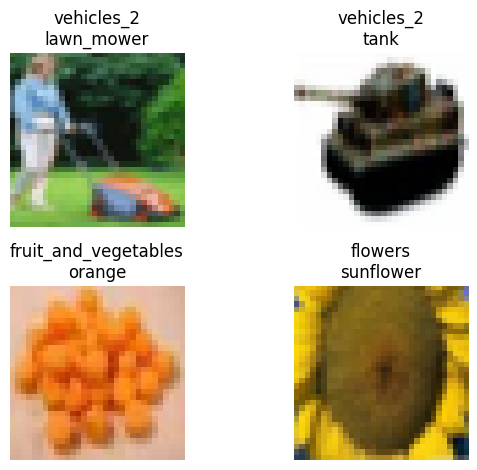

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(f'{y0_labels[y0_samples[axis_idx]]}\n{y1_labels[y1_samples[axis_idx]]}')
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

## Preprocessing the CIFAR-100 dataset

Let's load both the training and validation sets this time and pass them through our standard data pre-processing pipeline.

The inputs are transformed via our standard image-processing pipeline.

1. Resize images to the desired resolution. Here we resize them to $64 \times 64$ pixels
1. Rescale each pixel along each channel by a factor of $\frac{1}{255}$ so the resulting values reside in the range $[0, 1]$
1. Reorder the dimensions from NHWC to NCHW format

Let's one-hot encode our labels as well. This applies to both the coarse and fine labels. We'll split our training and validation sets into batches of $2 ^ 7 = 128$ samples for fine-tuning.

In [10]:
train_ds = mindcv.create_dataset('cifar100', split='train', download=True)
test_ds = mindcv.create_dataset('cifar100', split='test', download=True)

In [11]:
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms
from mindspore import dtype as mstype

def transform_ds(dataset):
    image_transforms = [
        vision.Resize(size=(64, 64)),
        vision.Rescale(rescale=1/255, shift=0),
        vision.HWC2CHW()
    ]
    coarse_label_transforms = [
        transforms.OneHot(num_classes=20),
        transforms.TypeCast(data_type=mstype.float32)
    ]
    fine_label_transforms = [
        transforms.OneHot(num_classes=100),
        transforms.TypeCast(data_type=mstype.float32)
    ]
    dataset = dataset.map(operations=image_transforms, input_columns='image')
    dataset = dataset.map(operations=coarse_label_transforms, input_columns='coarse_label')
    dataset = dataset.map(operations=fine_label_transforms, input_columns='fine_label')
    dataset = dataset.batch(batch_size=128, drop_remainder=False)
    return dataset

train_ds, test_ds = transform_ds(dataset=train_ds), transform_ds(dataset=test_ds)
train_ds, test_ds

(<mindspore.dataset.engine.datasets.BatchDataset at 0xe7feec15c230>,
 <mindspore.dataset.engine.datasets.BatchDataset at 0xe7feec15d7f0>)

## Loading ResNet-18 pretrained from ImageNet

Although it appears undocumented, we can use `list_models` from MindCV with a wildcard name `resnet*` to list the available pre-trained ResNet models. We'll use ResNet-18 so the fine-tuning process completes on our development board within a reasonable timeframe, e.g. 2 hours.

In [12]:
resnet_pretrained = mindcv.list_models('resnet*', pretrained=True)
resnet_pretrained

['resnet101',
 'resnet152',
 'resnet18',
 'resnet34',
 'resnet50',
 'resnetv2_101',
 'resnetv2_50']

Load the pretrained model with [`mindcv.create_model`](https://mindspore-lab.github.io/mindcv/reference/models/#create-model).

In [13]:
resnet18 = mindcv.create_model('resnet18', pretrained=True)
resnet18

ResNet(
  (conv1): Conv2d(input_channels=3, output_channels=64, kernel_size=(7, 7), stride=(2, 2), pad_mode=pad, padding=3, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xe7feec36a240>, bias_init=None, format=NCHW)
  (bn1): BatchNorm2d(num_features=64, eps=1e-05, momentum=0.9, gamma=Parameter (name=bn1.gamma, shape=(64,), dtype=Float32, requires_grad=True), beta=Parameter (name=bn1.beta, shape=(64,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=bn1.moving_mean, shape=(64,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=bn1.moving_variance, shape=(64,), dtype=Float32, requires_grad=False))
  (relu): ReLU()
  (max_pool): MaxPool2d(kernel_size=3, stride=2, pad_mode=SAME)
  (layer1): SequentialCell(
    (0): BasicBlock(
      (conv1): Conv2d(input_channels=64, output_channels=64, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, padding=1, dilation=(1, 1), group=1, has_bias=False, weight_ini

## Adapting ResNet-18 for hierarchical classification with CIFAR-100

For our hierarchical classification task, let's reuse the stem and body from ResNet-18 and replace the original  head consisting of a single classifier with 2 parallel FC layers - 1 for predicting the coarse labels and 1 for predicting the fine labels.

We'll then concatenate the $20 + 100$ logits from the coarse + fine predictions into a single tensor and return the result.

In [14]:
import mindspore.nn as nn

class MultiHeadResNet18(nn.Cell):
    def __init__(self, resnet18):
        super().__init__()
        self.backbone = nn.SequentialCell([
            resnet18.conv1,
            resnet18.bn1,
            resnet18.relu,
            resnet18.max_pool,
            resnet18.layer1,
            resnet18.layer2,
            resnet18.layer3,
            resnet18.layer4,
            resnet18.pool,
            nn.Flatten()
        ])
        self.coarse_classifier = nn.Dense(512, 20)
        self.fine_classifier = nn.Dense(512, 100)

    def construct(self, X):
        y_hat = self.backbone(X)
        coarse_logits = self.coarse_classifier(y_hat)
        fine_logits = self.fine_classifier(y_hat)
        return ops.concat((coarse_logits, fine_logits), axis=-1)

In [15]:
multihead_resnet18 = MultiHeadResNet18(resnet18=resnet18)
multihead_resnet18

MultiHeadResNet18(
  (backbone): SequentialCell(
    (0): Conv2d(input_channels=3, output_channels=64, kernel_size=(7, 7), stride=(2, 2), pad_mode=pad, padding=3, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xe7feec36a240>, bias_init=None, format=NCHW)
    (1): BatchNorm2d(num_features=64, eps=1e-05, momentum=0.9, gamma=Parameter (name=backbone.1.gamma, shape=(64,), dtype=Float32, requires_grad=True), beta=Parameter (name=backbone.1.beta, shape=(64,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=backbone.1.moving_mean, shape=(64,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=backbone.1.moving_variance, shape=(64,), dtype=Float32, requires_grad=False))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, pad_mode=SAME)
    (4): SequentialCell(
      (0): BasicBlock(
        (conv1): Conv2d(input_channels=64, output_channels=64, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, p

Let's wrap our model with [`mindspore.amp.auto_mixed_precision`](https://www.mindspore.cn/docs/en/r2.9.0/api_python/amp/mindspore.amp.auto_mixed_precision.html) to handle the type casting between FP32 and FP16 automatically. This saves us the effort of doing it manually.

In [16]:
import mindspore.amp as amp

multihead_resnet18_amp = amp.auto_mixed_precision(network=multihead_resnet18, amp_level='O2')
multihead_resnet18_amp

_OutputTo32(
  (_backbone): MultiHeadResNet18(
    (backbone): SequentialCell(
      (0): Conv2d(input_channels=3, output_channels=64, kernel_size=(7, 7), stride=(2, 2), pad_mode=pad, padding=3, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xe7feec36a240>, bias_init=None, format=NCHW)
      (1): _OutputTo16(
        (_backbone): BatchNorm2d(num_features=64, eps=1e-05, momentum=0.9, gamma=Parameter (name=backbone.1.gamma, shape=(64,), dtype=Float32, requires_grad=True), beta=Parameter (name=backbone.1.beta, shape=(64,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=backbone.1.moving_mean, shape=(64,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=backbone.1.moving_variance, shape=(64,), dtype=Float32, requires_grad=False))
      )
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, pad_mode=SAME)
      (4): SequentialCell(
        (0): BasicBlock(
          (conv1): Conv2d(inp

Create a dummy RGB "image" of $64 \times 64$ pixels and inspect the output shape from our network. Since we have 20 raw logits for the coarse labels and 100 for the fine labels, we should output a total of $20 + 100 = 120$ logits per image.

In [17]:
import mindspore.ops as ops

X_rgb_64x64 = ops.randn(1, 3, 64, 64)
y_hat = multihead_resnet18_amp(X_rgb_64x64)
y_hat.shape

/usr/local/Ascend/cann-9.0.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:179: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/c

(1, 120)

## Defining our hierarchical loss function for CIFAR-100

Let's define our loss function. Since there is a hierarchical relationship between the coarse and fine labels, we should mirror this relationship in our loss function.

1. Compute the softmax cross-entropy loss for the coarse predictions. Denote the loss as $l_{\text{coarse}}$
1. Compute the softmax cross-entropy loss for the fine predictions. Denote the loss as $l_{\text{fine}}$
1. Define the hierarchical loss as $l = l_{\text{coarse}} + \lambda \cdot l_{\text{fine}}$ where $\lambda$ is a hyperparameter in the range $[0, 1]$

The idea is that we should penalize an incorrect prediction of the coarse label more severely compared to an incorrect prediction of the fine label. It might be easy for our model to mistake an apple for a pear but at least it shouldn't mistake a person for a tree!

For our purposes in this notebook experiment, let's set $\lambda = 0.5$ to strike a balance between penalizing incorrect fine label predictions too heavily and ensuring that our model learns the fine labels quick enough within a limited number of epochs. We'll fine-tune our model over 10 epochs as it takes just under 2 hours to do so with our OrangePi AIpro \(20T\) development board which is a marginally reasonable timeframe.

In [18]:
class HierarchicalLoss(nn.Cell):
    def __init__(self, lambd=0.5, reduction='mean'):
        super().__init__()
        self.lambd = lambd
        self.reduction = reduction
        self.ce = nn.SoftmaxCrossEntropyWithLogits(reduction=reduction)

    def construct(self, logits, labels):
        coarse_logits, fine_logits = logits[:, :20], logits[:, 20:]
        coarse_labels, fine_labels = labels

        coarse_loss = self.ce(coarse_logits, coarse_labels)
        fine_loss = self.ce(fine_logits, fine_labels)

        return coarse_loss + self.lambd * fine_loss

In [19]:
loss_fn = HierarchicalLoss(lambd=0.5, reduction='mean')
loss_fn

HierarchicalLoss(
  (ce): SoftmaxCrossEntropyWithLogits()
)

## Model fine-tuning and evaluation

Let's use minibatch SGD as our optimizer with a learning rate of `1e-3` for faster convergence within 10 epochs. For a fine-tuning task like this one, `1e-3` is already considered aggressive as we risk destroying the pre-trained image filters. Usually, a learning rate of `1e-4` will suffice.

In [20]:
optimizer = nn.SGD(params=multihead_resnet18_amp.trainable_params(), learning_rate=1e-3)
optimizer

SGD()

Define our forward and gradient functions as usual.

In [21]:
def forward(X, y):
    y_hat = multihead_resnet18_amp(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn = mindspore.value_and_grad(fn=forward, grad_position=None, weights=optimizer.parameters, has_aux=True)

Now define our training logic per batch and per epoch. This is mostly similar to what we've seen before except our dataset now returns 2 sets of labels \(coarse and fine\) instead of 1 which we must accommodate for.

In [22]:
def train_batch(X_batch, y_batch):
    (loss, _), grads = grad_fn(X_batch, y_batch)
    optimizer(grads)
    return loss

def train_epoch(epoch=0):
    print(f'Epoch {epoch} start')
    batch_count = train_ds.get_dataset_size()
    training_losses = []
    multihead_resnet18_amp.set_train()
    for batch_idx, (X_batch, y0_batch, y1_batch) in enumerate(train_ds.create_tuple_iterator()):
        loss = train_batch(X_batch, (y0_batch, y1_batch))
        if batch_idx % 20 == 0:
            print(f'Training loss: {loss.asnumpy():.4f} [{batch_idx}/{batch_count}]')
        training_losses.append(loss)
    print(f'Epoch {epoch} end')
    return training_losses

Define the validation logic as well. Again, the only real difference is accommodating both the coarse and fine labels.

In [23]:
def validate_epoch(epoch=0):
    validation_losses = []
    multihead_resnet18_amp.set_train(False)
    for X_batch, y0_batch, y1_batch in test_ds.create_tuple_iterator():
        batch_size = X_batch.shape[0]
        y_hat = multihead_resnet18_amp(X_batch)
        validation_loss = (batch_size, loss_fn(y_hat, (y0_batch, y1_batch)).item())
        validation_losses.append(validation_loss)
    val_samples_total = sum(batch_size for batch_size, _ in validation_losses)
    val_loss = sum(batch_size * batch_loss for batch_size, batch_loss in validation_losses) / val_samples_total
    print(f'Validation loss after epoch {epoch}: {val_loss:.4f}')
    return val_loss

Fine-tune our model over 10 epochs. Be patient - this will take just under 2 hours to complete on our development board.

In [24]:
training_losses = []
validation_losses = []
epochs = 10

In [25]:
print(f'Fine-tuning our model over {epochs} epochs ...')

for epoch in range(epochs):
    training_losses.extend(train_epoch(epoch=epoch))
    validation_losses.append(validate_epoch(epoch=epoch))

training_losses, validation_losses = ops.stack(training_losses, axis=0), mindspore.Tensor(validation_losses)
training_losses.shape, validation_losses.shape

Fine-tuning our model over 10 epochs ...
Epoch 0 start
..Training loss: 5.6848 [0/391]
Training loss: 5.4499 [20/391]
Training loss: 5.3580 [40/391]
Training loss: 5.3982 [60/391]
Training loss: 5.3181 [80/391]
Training loss: 5.3137 [100/391]
Training loss: 5.1766 [120/391]
Training loss: 5.1904 [140/391]
Training loss: 5.0723 [160/391]
Training loss: 5.0245 [180/391]
Training loss: 4.9998 [200/391]
Training loss: 4.7842 [220/391]
Training loss: 4.9190 [240/391]
Training loss: 4.9942 [260/391]
Training loss: 4.8681 [280/391]
Training loss: 4.7217 [300/391]
Training loss: 4.6198 [320/391]
Training loss: 4.7625 [340/391]
Training loss: 4.4851 [360/391]
Training loss: 4.7031 [380/391]
path string is NULLpath string is NULL.Epoch 0 end
Validation loss after epoch 0: 4.5388
Epoch 1 start
Training loss: 4.4457 [0/391]
Training loss: 4.5591 [20/391]
Training loss: 4.3686 [40/391]
Training loss: 4.4903 [60/391]
Training loss: 4.4057 [80/391]
Training loss: 4.2155 [100/391]
Training loss: 4.119

((3910,), (10,))

Let's plot the training vs. validation loss with Matplotlib.

.

/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:97: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:157: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:97: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:157: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)


..

/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:97: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:157: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:97: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-9.0.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:157: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)


...

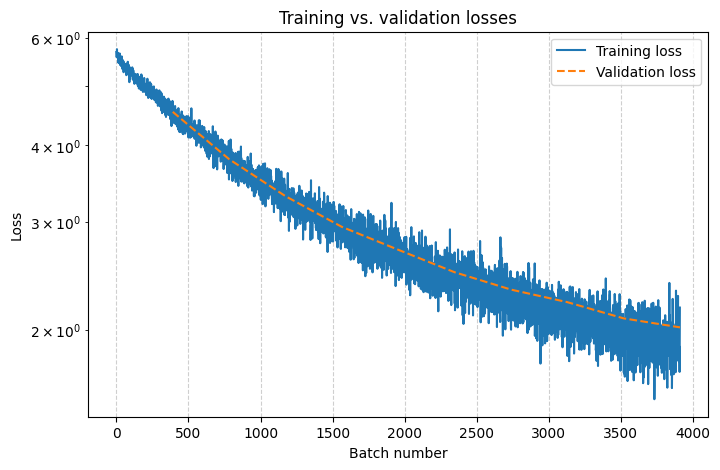

In [26]:
import numpy as np

batches_per_epoch = 391
batches_x = np.arange(batches_per_epoch * epochs)
epochs_x = np.arange(epochs) * batches_per_epoch + batches_per_epoch
training_losses_y = training_losses.asnumpy()
validation_losses_y = validation_losses.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(batches_x, training_losses_y, label='Training loss', linestyle='-')
plt.plot(epochs_x, validation_losses_y, label='Validation loss', linestyle='--')

plt.title('Training vs. validation losses')
plt.xlabel('Batch number')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

Finally, let's evaluate the accuracy of our model with 3 metrics.

1. Coarse accuracy: the proportion of coarse labels which our model predicted correctly
1. Fine accuracy: same as \(1\) but for fine labels
1. Hierarchical accuracy: the true accuracy, each prediction is considered correct only if _both_ the coarse and fine predictions match their corresponding labels

In [27]:
multihead_resnet18_amp.set_train(False)
coarse_accs, fine_accs, true_accs = [], [], []
for X_batch, y0_batch, y1_batch in test_ds.create_tuple_iterator():
    batch_size = X_batch.shape[0]
    y_hat = multihead_resnet18_amp(X_batch)
    y0_hat, y1_hat = y_hat[:, :20], y_hat[:, 20:]
    y0_hat, y1_hat = ops.argmax(y0_hat, dim=1), ops.argmax(y1_hat, dim=1)
    y0_batch, y1_batch = ops.argmax(y0_batch, dim=1), ops.argmax(y1_batch, dim=1)
    y0_correct, y1_correct = (y0_hat == y0_batch).sum().item(), (y1_hat == y1_batch).sum().item()
    y0_acc, y1_acc = y0_correct / batch_size, y1_correct / batch_size
    coarse_accs.append((batch_size, y0_acc))
    fine_accs.append((batch_size, y1_acc))
    y_hat, y_batch = ops.stack((y0_hat, y1_hat), axis=1), ops.stack((y0_batch, y1_batch), axis=1)
    y_correct = ops.amin((y_hat == y_batch).astype(dtype=mstype.int32), axis=1).sum().item()
    y_acc = y_correct / batch_size
    true_accs.append((batch_size, y_acc))
val_samples_total = sum(batch_size for batch_size, _ in true_accs)
coarse_acc = sum(batch_size * y0_acc for batch_size, y0_acc in coarse_accs) / val_samples_total
fine_acc = sum(batch_size * y1_acc for batch_size, y1_acc in fine_accs) / val_samples_total
true_acc = sum(batch_size * y_acc for batch_size, y_acc in true_accs) / val_samples_total
print(f'Coarse accuracy: {coarse_acc:.4f}')
print(f'Fine accuracy: {fine_acc:.4f}')
print(f'True accuracy: {true_acc:.4f}')

.Coarse accuracy: 0.6987
Fine accuracy: 0.4645
True accuracy: 0.4251


The coarse accuracy is close to $70\%$ and the hierarchical accuracy is over $40\%$ - not bad!

## Concluding remarks and going further

We saw in this notebook experiment how to load ResNet-18 with pre-trained weights using MindCV and use it for transfer learning by fine-tuning the pre-trained model on the CIFAR-100 dataset using MindSpore.

While fine-tuning a modern CNN such as ResNet-18 is interesting in its own right, it's nevertheless just the tip of the iceberg in the field of transfer learning and we have yet to explore practical techniques of transfer learning relevant to modern deep learning. As we continue in our deep learning journey, we'll likely cover LLM [parameter-efficient fine-tuning \(PEFT\)](https://arxiv.org/abs/2312.12148) techniques such as LoRA in a future notebook experiment. PEFT enables modern ML practitioners to quickly adapt an existing LLM to a specific domain by freezing the original model weights and attaching a small set of new weights for training, greatly reducing the time, effort and resources required for LLM fine-tuning.

I hope you enjoyed following through this notebook experiment as much as I did authoring it and stay tuned for updates ;-\)